In [1]:
import sinter
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

FIG_DPI = 300
mpl.style.use("plotstyles.mlpstyle")

pymatching_pauli_noise_threshold = 0.00775
PYMATCHING_FILES = [
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=pymatching/2025-11-28.csv"
]
pymatching_stats = sinter.read_stats_from_csv_files(*PYMATCHING_FILES)
pymatching_stats = [
    s
    for s in pymatching_stats
    if s.json_metadata.get("p") <= pymatching_pauli_noise_threshold
]
pymatching_stats

[sinter.TaskStats(strong_id='c66be70a4982a33c5221ac48ab9201aeb504e79f1f4bfbffd144ebdb938b06f1', decoder='pymatching', json_metadata={'circuit': 'surface_code:rotated_memory_x', 'cluster_node_limit': None, 'd': 3, 'decoder': 'pymatching', 'decoder_type': None, 'p': 0.0075, 'p_erase': 0.0, 'r': 3, 'run_id': '2abbd67f691a06be56a714841dbb3ffc69ff07228f5deb34fab16bef9900ebe0'}, shots=397585, errors=10016, seconds=0.17599999999999996),
 sinter.TaskStats(strong_id='bc5dfb6308bc207d4edca1ce7e29b7ae60ff51566b5756244d4e04da3cd34a12', decoder='pymatching', json_metadata={'circuit': 'surface_code:rotated_memory_x', 'cluster_node_limit': None, 'd': 3, 'decoder': 'pymatching', 'decoder_type': None, 'p': 0.003, 'p_erase': 0.0, 'r': 3, 'run_id': '316d27c500fbef5ef2d49d74701a6a526b36f12cf97b83e3262d07bcf4ab8728'}, shots=500000, errors=2281, seconds=0.13099999999999998),
 sinter.TaskStats(strong_id='090f281a5de906b3dfb814c9c6c0ee1f720eed38c2918b9c031f74b9e568a0d9', decoder='pymatching', json_metadata={'

In [2]:
mwpf_erasure_noise_threshold = 0.0275
ERASURE_FILES = [
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_d=3.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_d=5.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_d=7.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_d=9.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_d=11,p=0.01,0.02,0.03.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_memfix4_d=7.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_memfix4_d=9.csv",
]

erasure_stats = sinter.read_stats_from_csv_files(*ERASURE_FILES)
erasure_stats = [
    s
    for s in erasure_stats
    if s.json_metadata.get("p_erase") <= mwpf_erasure_noise_threshold
]
erasure_stats

[sinter.TaskStats(strong_id='269c086892560d2b2c3fb91f8240ee87c8e2f52d5b2ff0982c1e1b9fe1e015ae', decoder='mwpf__3a2de2621d93f2d1f82bf505831648faac50961c9682adb78978518126f61ad4', json_metadata={'circuit': 'surface_code:rotated_memory_x', 'cluster_node_limit': 50, 'd': 3, 'decoder': 'mwpf', 'decoder_type': 'SolverSerialJointSingleHair', 'p': 0.005, 'p_erase': 0.005, 'r': 3, 'run_id': '5101ac8ef9c97b83df4dd9d8fb12d7b219d036893929703eba32fffa9e647600'}, shots=500000, errors=112, seconds=19.192999999999998),
 sinter.TaskStats(strong_id='d994fe02c85cb3c768399acfffda9f01e9344d65a7427484376e8d07bf72dce7', decoder='mwpf__bbbb95ae8dfd216392d93d271ab853220d7a01380e740dc79365759e9487ffb2', json_metadata={'circuit': 'surface_code:rotated_memory_x', 'cluster_node_limit': 50, 'd': 3, 'decoder': 'mwpf', 'decoder_type': 'SolverSerialJointSingleHair', 'p': 0.004, 'p_erase': 0.004, 'r': 3, 'run_id': '90efa888ab0be85c6dc82d20d594fb219f455db906f7e8f7ad923a214270e30c'}, shots=500000, errors=65, seconds=17.1

In [3]:
mwpf_pauli_noise_threshold = 0.00650

ABLATION_FILES = [
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=0.0/solver=SolverSerialJointSingleHair/2025-11-27_d=3.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=0.0/solver=SolverSerialJointSingleHair/2025-11-27_d=5.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=0.0/solver=SolverSerialJointSingleHair/2025-11-27_d=7.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=0.0/solver=SolverSerialJointSingleHair/2025-11-27_d=9.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=SinterMWPFDecoder/erasure=0.0/solver=SolverSerialJointSingleHair/2025-11-30.csv",
]

ablation_stats = sinter.read_stats_from_csv_files(*ABLATION_FILES)
ablation_stats = [
    s for s in ablation_stats if s.json_metadata.get("p") <= mwpf_pauli_noise_threshold
]
for s in ablation_stats:
    # the naming scheme in util.sinter_task.DecoderLib changed slightly since last run
    if s.json_metadata.get("decoder") == "SinterMWPFDecoder":
        s.json_metadata["decoder"] = "mwpf"
ablation_stats

[sinter.TaskStats(strong_id='7ee21ac07e1d2d837dee1b9de812df8e43271af75c9d02b6bafea9ec15c9affa', decoder='mwpf__682d5c8b1e761a1076b65dca539a2d15d82ad086708269570743d5b5c12e48ec', json_metadata={'circuit': 'surface_code:rotated_memory_x', 'cluster_node_limit': 50, 'd': 3, 'decoder': 'mwpf', 'decoder_type': 'SolverSerialJointSingleHair', 'p': 0.0065, 'p_erase': 0.0, 'r': 3, 'run_id': 'b8f63b3afee4afe98e7bbb30f20c4398dd3b9aec649fcfb3e47705c2a2c61b36'}, shots=50000, errors=759, seconds=24.307),
 sinter.TaskStats(strong_id='529639a8efcc2d68bcd5753eb8355ddcaf6a93496022c9cf7dbfb051af66a68c', decoder='mwpf__b0f6649b21db54ecbb8826cdfafa1ba0e2bf46532f7acaf5414024d498b451a0', json_metadata={'circuit': 'surface_code:rotated_memory_x', 'cluster_node_limit': 50, 'd': 3, 'decoder': 'mwpf', 'decoder_type': 'SolverSerialJointSingleHair', 'p': 0.003, 'p_erase': 0.0, 'r': 3, 'run_id': '915e7fac76f0cb44d6aac79997be9e5a903d4aa353a8207f80b396814e1292cb'}, shots=50000, errors=164, seconds=6.487000000000002),


In [4]:
custom_pymatching_threshold = 0.008
PYMATCHING_CUSTOM_FILES = [
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=HeraldedEraseDecoder/erasure=1.0/2025-11-30_pthresh.csv"
]
custom_stats = sinter.read_stats_from_csv_files(*PYMATCHING_CUSTOM_FILES)
custom_stats = [
    s for s in custom_stats if s.json_metadata.get("p") <= custom_pymatching_threshold
]
custom_stats

[sinter.TaskStats(strong_id='3032dd73b5566e0fb287436271f91dfb0b621a9786c1fa1a24fa1a5ad213306f', decoder='HeraldedEraseDecoder.137504505080752', json_metadata={'circuit': 'surface_code:rotated_memory_x', 'cluster_node_limit': None, 'd': 3, 'decoder': 'HeraldedEraseDecoder', 'decoder_type': None, 'decoder_version': '0.0.1-dev1', 'p': 0.003, 'p_erase': 0.0, 'r': 3, 'run_id': 137504505080752, 'sinter_version': '1.16.dev1761611832', 'stim_version': '1.16.dev1761611832'}, shots=500000, errors=2379, seconds=26.759000000000007),
 sinter.TaskStats(strong_id='1c84ee6d14bde95dfb6905814ed263313e4a9dc31b8449d0b1930afd9e81157a', decoder='HeraldedEraseDecoder.137504505080752', json_metadata={'circuit': 'surface_code:rotated_memory_x', 'cluster_node_limit': None, 'd': 3, 'decoder': 'HeraldedEraseDecoder', 'decoder_type': None, 'decoder_version': '0.0.1-dev1', 'p': 0.006, 'p_erase': 0.0, 'r': 3, 'run_id': 137504505080752, 'sinter_version': '1.16.dev1761611832', 'stim_version': '1.16.dev1761611832'}, sh

In [5]:
import scipy.stats
import numpy as np

# project the code_distance needed to surface a trillion rounds at some p, just under the threshold


# Compute the line fit of code distance vs. logical error rate
# We expect logical error rates to decrease exponentially with code distance
def fit(sample_stats):
    xs = []
    ys = []
    log_ys = []
    for stats in sample_stats:
        d = stats.json_metadata["d"]
        if not stats.errors:
            print(f"Didn't see any errors for d={d}")
            continue
        per_shot = stats.errors / stats.shots
        per_round = sinter.shot_error_rate_to_piece_error_rate(
            per_shot, pieces=stats.json_metadata["r"]
        )
        xs.append(d)
        ys.append(per_round)
        log_ys.append(np.log(per_round))

    fit = scipy.stats.linregress(xs, log_ys)
    print(fit)
    return fit, xs, ys, log_ys

In [6]:
print("pymatching p_e=0 fit")
fit1, xs1, ys1, log_ys1 = fit(pymatching_stats)
print("mwpf fit")
fit2, xs2, ys2, log_ys2 = fit(erasure_stats)
print("HeraldedEraseDecoder fit")
fit3, xs3, ys3, log_ys3 = fit(custom_stats)

print("MWPF Ablation fit")
fit4, xs4, ys4, logys_4 = fit(ablation_stats)

pymatching p_e=0 fit
LinregressResult(slope=np.float64(-0.29767356543606016), intercept=np.float64(-4.528982878182173), rvalue=np.float64(-0.5882319901901178), pvalue=np.float64(8.798653898993915e-06), stderr=np.float64(0.059693352765603204), intercept_stderr=np.float64(0.5879113431008781))
mwpf fit
Didn't see any errors for d=5
Didn't see any errors for d=5
Didn't see any errors for d=5
Didn't see any errors for d=7
Didn't see any errors for d=7
Didn't see any errors for d=7
Didn't see any errors for d=7
Didn't see any errors for d=7
Didn't see any errors for d=7
Didn't see any errors for d=7
Didn't see any errors for d=7
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=11
Didn't see any errors for d=7
Didn't see any errors for d=7
Didn't s

In [7]:
df1 = pd.DataFrame({"x": xs1, "y": ys1})

df1.groupby("x").std()

,y
x,
3,0.002573
5,0.002216
7,0.001698
9,0.001334
11,0.001040
13,0.000834
15,0.000678


In [8]:
# fig, ax = plt.subplots()
# axins = inset_axes(ax, width="40%", height="40%", loc="lower right", borderpad=1.5)
# axins.semilogy()

# ax.tick_params(axis="both", which="both", labelsize=8)
# axins.tick_params(axis="both", which="both", labelsize=6)

# scatter1 = ax.scatter(
#     xs1,
#     ys1,
#     label=f"Exp#1, $R_e$=0 PyMatching",
#     s=30,
#     color="tab:blue",
#     marker="o",
# )
# axins.scatter(
#     xs1,
#     ys1,
#     label=f"Exp#1, $R_e$=0 PyMatching",
#     s=2,
#     color="tab:blue",
#     marker="o",
# )
# ax.plot(
#     [0, 150],
#     [np.exp(fit1.intercept), np.exp(fit1.intercept + fit1.slope * 150)],
#     linestyle="--",
#     label="least squares fit",
#     color="tab:blue",
# )
# (fitline1,) = axins.plot(
#     [0, 150],
#     [np.exp(fit1.intercept), np.exp(fit1.intercept + fit1.slope * 150)],
#     linestyle="--",
#     label="least squares fit",
#     color="tab:blue",
# )


# axins.scatter(
#     xs4,
#     ys4,
#     label=f"Exp#2 $R_e$=0 MWPF",
#     s=2,
#     color="tab:orange",
#     marker="d",
#     alpha=0.5,
# )
# (fitline2,) = axins.plot(
#     [0, 80],
#     [np.exp(fit4.intercept), np.exp(fit4.intercept + fit4.slope * 80)],
#     linestyle="--",
#     label="least squares line fit",
#     color="tab:orange",
#     alpha=0.5,
# )


# axins.scatter(
#     xs2, ys2, label=f"Exp#3 $R_e$=1 MWPF", s=2, color="tab:green", marker="*", alpha=0.5
# )
# axins.plot(
#     [0, 80],
#     [np.exp(fit2.intercept), np.exp(fit2.intercept + fit2.slope * 80)],
#     linestyle="--",
#     label="least squares line fit",
#     color="tab:green",
# )


# axins.scatter(
#     xs3, ys3, label=f"Exp#4 $R_e$=1 PyMatching", s=2, color="tab:red", marker="s"
# )
# axins.plot(
#     [0, 80],
#     [np.exp(fit3.intercept), np.exp(fit3.intercept + fit3.slope * 80)],
#     linestyle="--",
#     label="least squares line fit",
#     color="tab:red",
# )

# axins.set_ylim(1e-12, 1e-2)
# axins.set_xlim(1, 80)
# ax.set_ylim(1e-6, 1e-2)
# ax.set_xlim(1, 30)
# ax.semilogy()
# ax.set_title("Code distance to survive one trillion rounds, $p < p_{thr}$")
# ax.set_xlabel("Code Distance $d$")
# ax.set_ylabel("Logical Error Rate per Round $P_L$")
# ax.grid(which="major")
# # ax.grid(which="minor")
# # ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))

# ax.legend(handles=[scatter1, fitline1, scatter2, scatter3, scatter4])
# ax.grid(True)
# fig.set_dpi(200)
# fig.tight_layout()

In [9]:
# fig, ax = plt.subplots()

# ax.tick_params(axis="both", which="both", labelsize=8)
# axins.tick_params(axis="both", which="both", labelsize=6)

# scatter1 = ax.scatter(
#     xs1,
#     ys1,
#     label=f"Exp#1, $R_e$=0 PyMatching",
#     s=15,
#     color="tab:blue",
#     marker="o",
#     alpha=0.5,
# )

# ax.plot(
#     [0, 150],
#     [np.exp(fit1.intercept), np.exp(fit1.intercept + fit1.slope * 150)],
#     linestyle="--",
#     label="least squares fit",
#     color="tab:blue",
# )

# scatter2 = ax.scatter(
#     xs4,
#     ys4,
#     label=f"Exp#2 $R_e$=0 MWPF",
#     s=15,
#     color="tab:orange",
#     marker="d",
#     alpha=0.5,
# )
# ax.plot(
#     [0, 80],
#     [np.exp(fit4.intercept), np.exp(fit4.intercept + fit4.slope * 80)],
#     linestyle="--",
#     label="least squares line fit",
#     color="tab:orange",
# )

# scatter3 = ax.scatter(
#     xs2,
#     ys2,
#     label=f"Exp#3 $R_e$=1 MWPF",
#     s=15,
#     color="tab:green",
#     marker="*",
#     alpha=0.5,
# )
# ax.plot(
#     [0, 80],
#     [np.exp(fit2.intercept), np.exp(fit2.intercept + fit2.slope * 80)],
#     linestyle="--",
#     label="least squares line fit",
#     color="tab:green",
# )


# scatter4 = ax.scatter(
#     xs3,
#     ys3,
#     label=f"Exp#4 $R_e$=1 PyMatching",
#     s=15,
#     color="tab:brown",
#     marker="s",
#     alpha=0.5,
# )
# ax.plot(
#     [0, 80],
#     [np.exp(fit3.intercept), np.exp(fit3.intercept + fit3.slope * 80)],
#     linestyle="--",
#     label="least squares line fit",
#     color="tab:brown",
# )

# ax.set_ylim(1e-7, 1e-2)
# ax.set_xlim(1, 17)
# ax.semilogy()
# ax.set_title("Code distance to survive one trillion rounds, $p < p_{thr}$")
# ax.set_xlabel("Code Distance $d$")
# ax.set_ylabel("Logical Error Rate per Round $P_L$")
# ax.grid(which="major")
# # ax.grid(which="minor")
# # ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))

# ax.legend(
#     handles=[scatter1, fitline1, scatter2, scatter3, scatter4],
#     loc="lower left",
#     fontsize=6,
# )
# ax.grid(True)
# fig.set_dpi(200)
# fig.tight_layout()

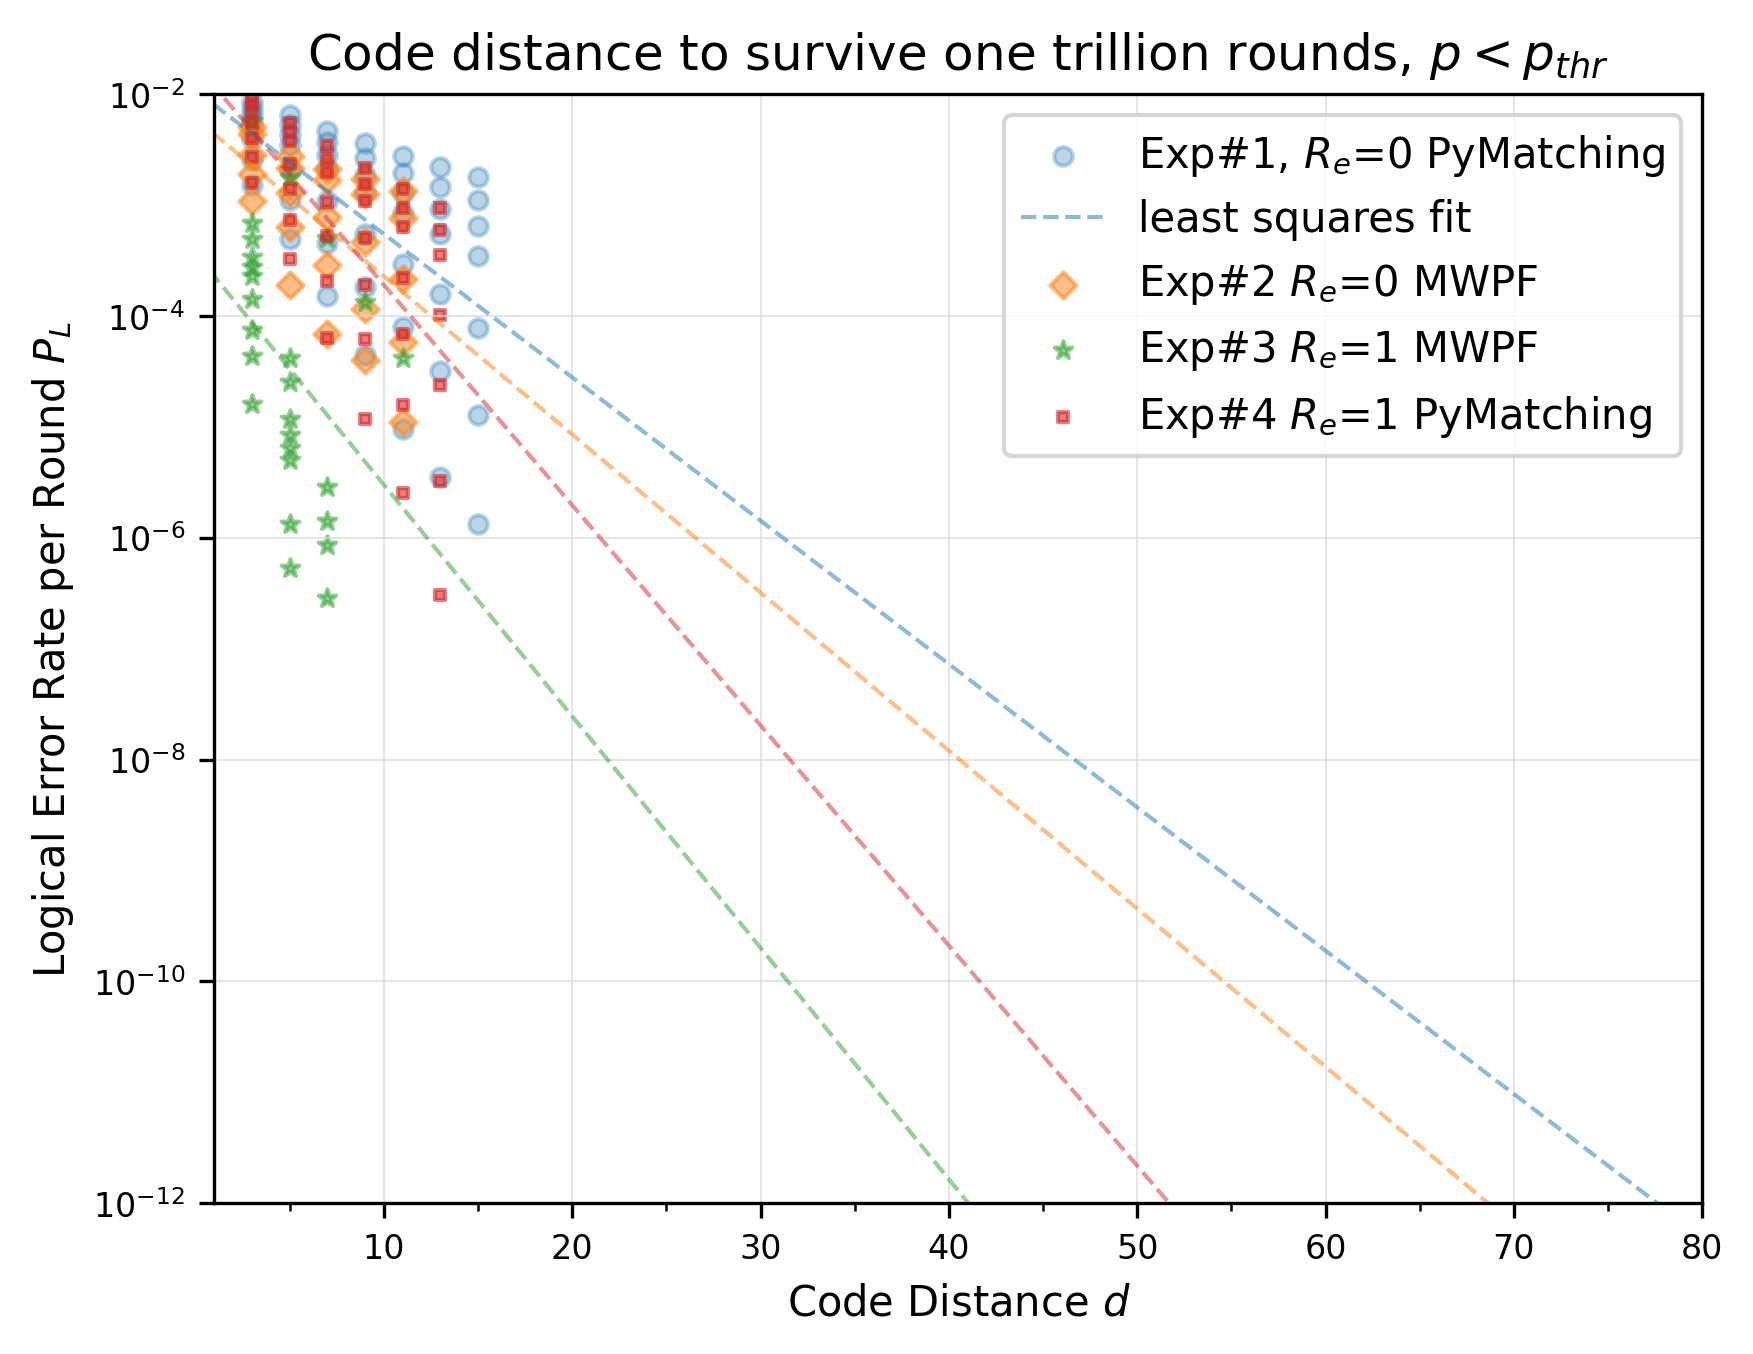

In [ ]:
fig, ax = plt.subplots()

ax.tick_params(axis="both", which="both", labelsize=8)

scatter1 = ax.scatter(
    xs1,
    ys1,
    label=f"Exp#1, $R_e$=0 PyMatching",
    s=20,
    color="tab:blue",
    marker="o",
    alpha=0.3,
)
(fitline1,) = ax.plot(
    [0, 150],
    [np.exp(fit1.intercept), np.exp(fit1.intercept + fit1.slope * 150)],
    linestyle="--",
    label="least squares fit",
    color="tab:blue",
    alpha=0.5,
)

scatter2 = ax.scatter(
    xs4,
    ys4,
    label=f"Exp#2 $R_e$=0 MWPF",
    s=20,
    color="tab:orange",
    marker="D",
    alpha=0.5,
)

ax.plot(
    [0, 80],
    [np.exp(fit4.intercept), np.exp(fit4.intercept + fit4.slope * 80)],
    linestyle="--",
    label="least squares line fit",
    color="tab:orange",
    alpha=0.5,
)

scatter3 = ax.scatter(
    xs2,
    ys2,
    label=f"Exp#3 $R_e$=1 MWPF",
    s=20,
    color="tab:green",
    marker="*",
    alpha=0.5,
)
ax.plot(
    [0, 80],
    [np.exp(fit2.intercept), np.exp(fit2.intercept + fit2.slope * 80)],
    linestyle="--",
    label="least squares line fit",
    color="tab:green",
    alpha=0.5,
)


scatter4 = ax.scatter(
    xs3,
    ys3,
    label=f"Exp#4 $R_e$=1 PyMatching",
    s=5,
    color="tab:red",
    marker="s",
    alpha=0.6,
)

ax.plot(
    [0, 80],
    [np.exp(fit3.intercept), np.exp(fit3.intercept + fit3.slope * 80)],
    linestyle="--",
    label="least squares line fit",
    color="tab:red",
    alpha=0.5,
)

ax.set_ylim(1e-12, 1e-2)
ax.set_xlim(1, 80)
ax.semilogy()
ax.set_title("Code distance to survive one trillion rounds, $p < p_{thr}$")
ax.set_xlabel("Code Distance $d$")
ax.set_ylabel("Logical Error Rate per Round $P_L$")
# ax.grid(which="minor")
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))

ax.legend(handles=[scatter1, fitline1, scatter2, scatter3, scatter4])
ax.grid(visible=True, which="major", linewidth=0.4, alpha=0.8)
fig.set_dpi(FIG_DPI)
plt.savefig(
    "../poster/images/dthr_survive_1T_rounds.png", bbox_inches="tight", dpi=FIG_DPI
)

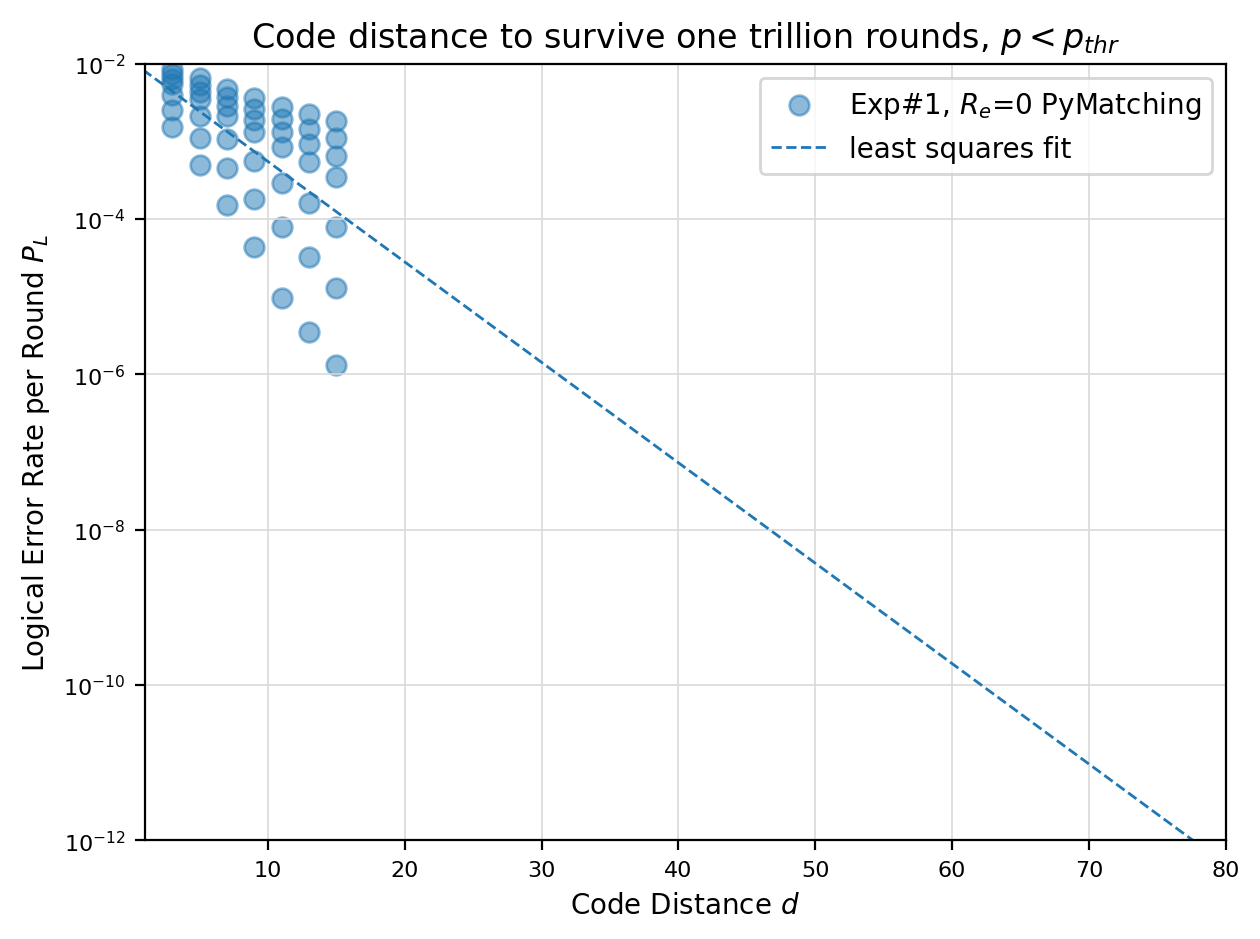

In [11]:
fig, ax = plt.subplots()

ax.tick_params(axis="both", which="both", labelsize=8)

scatter1 = ax.scatter(
    xs1,
    ys1,
    label=f"Exp#1, $R_e$=0 PyMatching",
    s=50,
    color="tab:blue",
    marker="o",
    alpha=0.5,
)
ax.plot(
    [0, 150],
    [np.exp(fit1.intercept), np.exp(fit1.intercept + fit1.slope * 150)],
    linestyle="--",
    label="least squares fit",
    color="tab:blue",
)

ax.set_ylim(1e-12, 1e-2)
ax.set_xlim(1, 80)
ax.semilogy()
ax.set_title("Code distance to survive one trillion rounds, $p < p_{thr}$")
ax.set_xlabel("Code Distance $d$")
ax.set_ylabel("Logical Error Rate per Round $P_L$")
ax.grid(which="major")
# ax.grid(which="minor")
# ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))

ax.legend()
ax.grid(True)
fig.set_dpi(200)
fig.tight_layout()

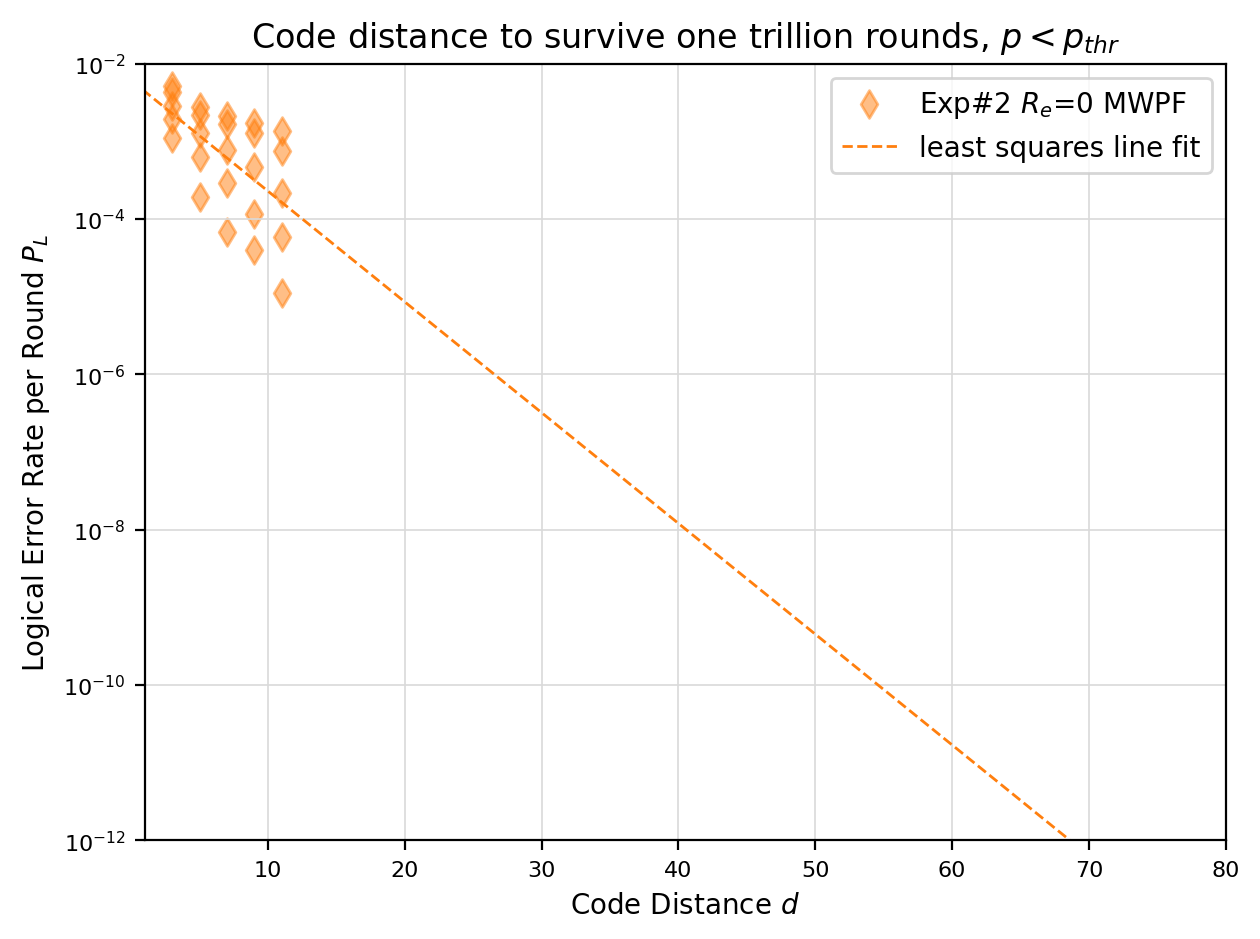

In [12]:
fig, ax = plt.subplots()

ax.tick_params(axis="both", which="both", labelsize=8)


scatter2 = ax.scatter(
    xs4,
    ys4,
    label=f"Exp#2 $R_e$=0 MWPF",
    s=50,
    color="tab:orange",
    marker="d",
    alpha=0.5,
)

ax.plot(
    [0, 80],
    [np.exp(fit4.intercept), np.exp(fit4.intercept + fit4.slope * 80)],
    linestyle="--",
    label="least squares line fit",
    color="tab:orange",
)


ax.set_ylim(1e-12, 1e-2)
ax.set_xlim(1, 80)
ax.semilogy()
ax.set_title("Code distance to survive one trillion rounds, $p < p_{thr}$")
ax.set_xlabel("Code Distance $d$")
ax.set_ylabel("Logical Error Rate per Round $P_L$")
ax.grid(which="major")
# ax.grid(which="minor")
# ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))

ax.legend()
ax.grid(True)
fig.set_dpi(200)
fig.tight_layout()

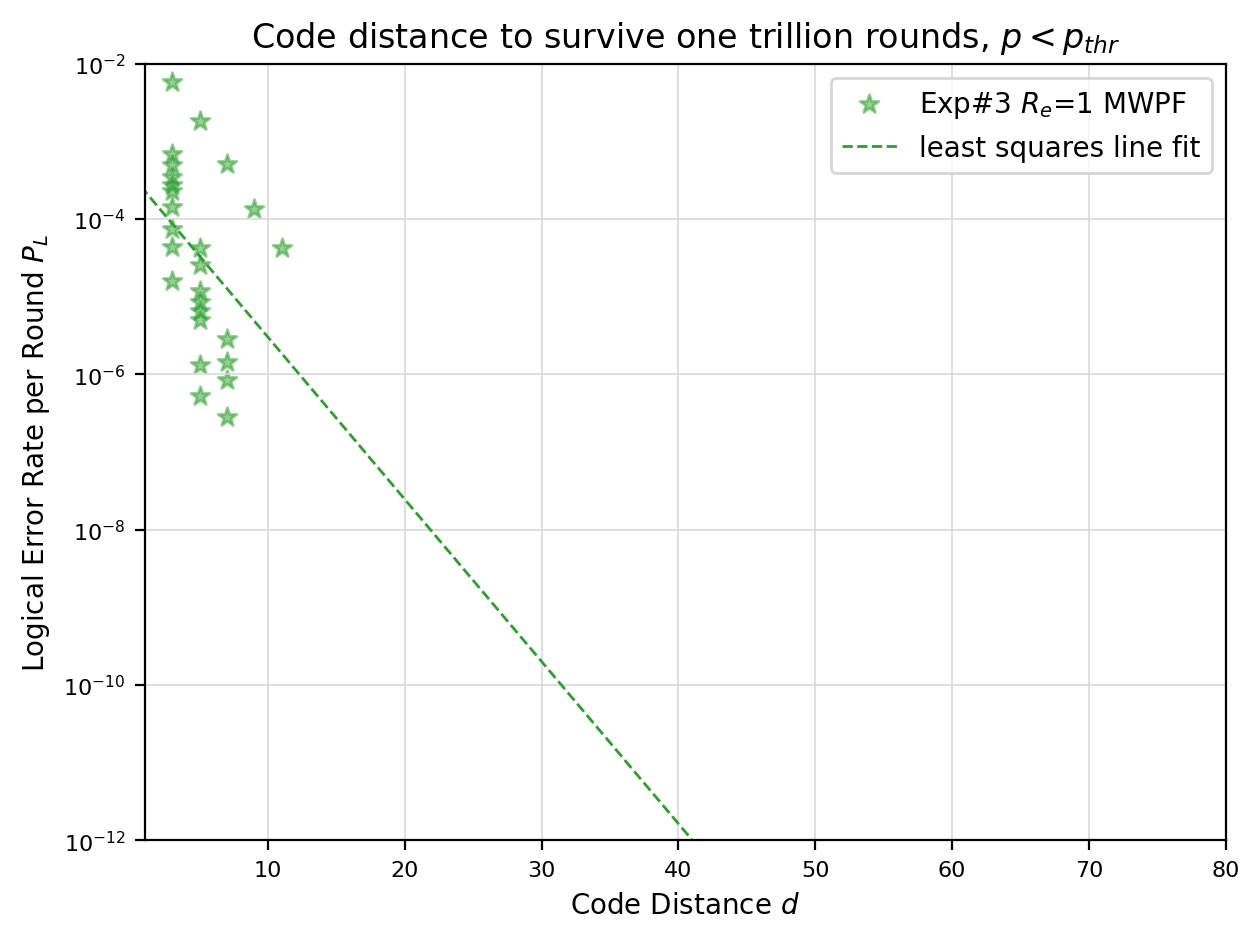

In [13]:
fig, ax = plt.subplots()

ax.tick_params(axis="both", which="both", labelsize=8)


scatter3 = ax.scatter(
    xs2,
    ys2,
    label=f"Exp#3 $R_e$=1 MWPF",
    s=50,
    color="tab:green",
    marker="*",
    alpha=0.5,
)
ax.plot(
    [0, 80],
    [np.exp(fit2.intercept), np.exp(fit2.intercept + fit2.slope * 80)],
    linestyle="--",
    label="least squares line fit",
    color="tab:green",
)


ax.set_ylim(1e-12, 1e-2)
ax.set_xlim(1, 80)
ax.semilogy()
ax.set_title("Code distance to survive one trillion rounds, $p < p_{thr}$")
ax.set_xlabel("Code Distance $d$")
ax.set_ylabel("Logical Error Rate per Round $P_L$")
ax.grid(which="major")
# ax.grid(which="minor")
# ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))

ax.legend()
ax.grid(True)
fig.set_dpi(200)
fig.tight_layout()

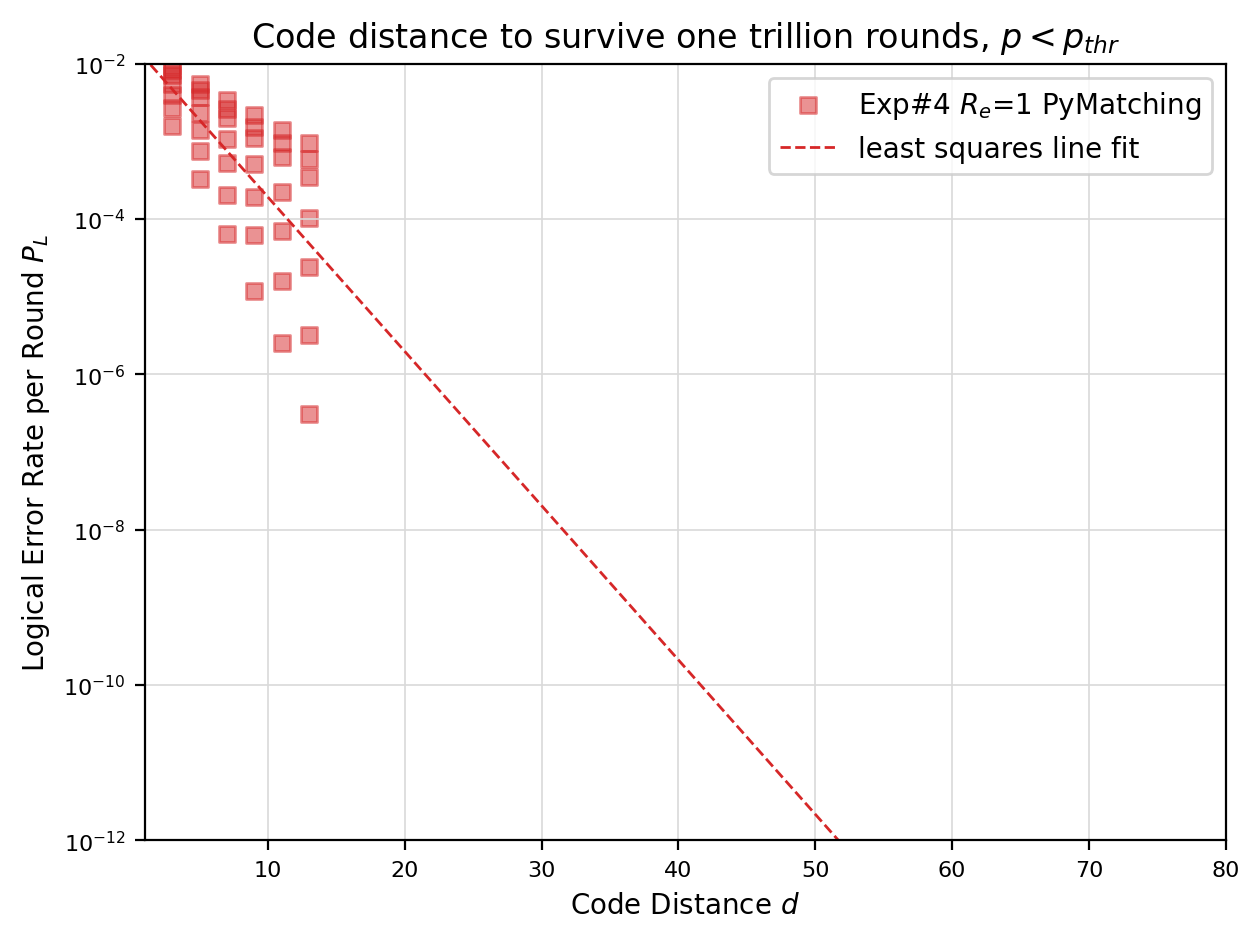

In [14]:
fig, ax = plt.subplots()

ax.tick_params(axis="both", which="both", labelsize=8)


scatter4 = ax.scatter(
    xs3,
    ys3,
    label=f"Exp#4 $R_e$=1 PyMatching",
    s=30,
    color="tab:red",
    marker="s",
    alpha=0.5,
)

ax.plot(
    [0, 80],
    [np.exp(fit3.intercept), np.exp(fit3.intercept + fit3.slope * 80)],
    linestyle="--",
    label="least squares line fit",
    color="tab:red",
)

ax.set_ylim(1e-12, 1e-2)
ax.set_xlim(1, 80)
ax.semilogy()
ax.set_title("Code distance to survive one trillion rounds, $p < p_{thr}$")
ax.set_xlabel("Code Distance $d$")
ax.set_ylabel("Logical Error Rate per Round $P_L$")
ax.grid(which="major")
# ax.grid(which="minor")
# ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))

ax.legend()
ax.grid(True)
fig.set_dpi(200)
fig.tight_layout()